# Food Recipe 

## 1. Imports & Setup


In [2]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import (
    ExtraTreesClassifier,
    RandomForestClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
N_TRIALS = 75
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (8, 4),
    "figure.dpi": 100,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})


/Users/henricusbracht/Documents/Studium/Master/Module/2nd Sem/Machine Learning/Final Data CHallenge/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Loading


In [3]:
for cand in [Path("."), Path("data")]:
    if (cand / "train.csv").exists():
        DATA_DIR = cand
        break

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

feature_cols = [c for c in train.columns if c != "y"]
X = train[feature_cols]
y = train["y"]
X_test = test[feature_cols]

assert len(feature_cols) == 40
assert set(y.unique()) == {1, 2}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"DATA_DIR: {DATA_DIR.resolve()}")
print(f"train: {train.shape} | test: {test.shape} | features: {len(feature_cols)}")
print("Class balance (proportion):")
print(y.value_counts(normalize=True).sort_index().round(3))


DATA_DIR: /Users/henricusbracht/Documents/Studium/Master/Module/2nd Sem/Machine Learning/Final Data CHallenge
train: (3200, 41) | test: (1734, 40) | features: 40
Class balance (proportion):
y
1    0.515
2    0.485
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis.


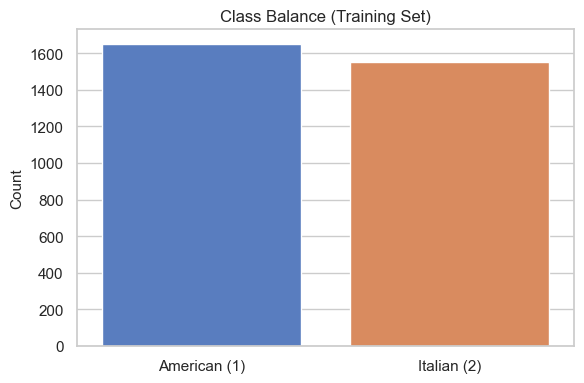

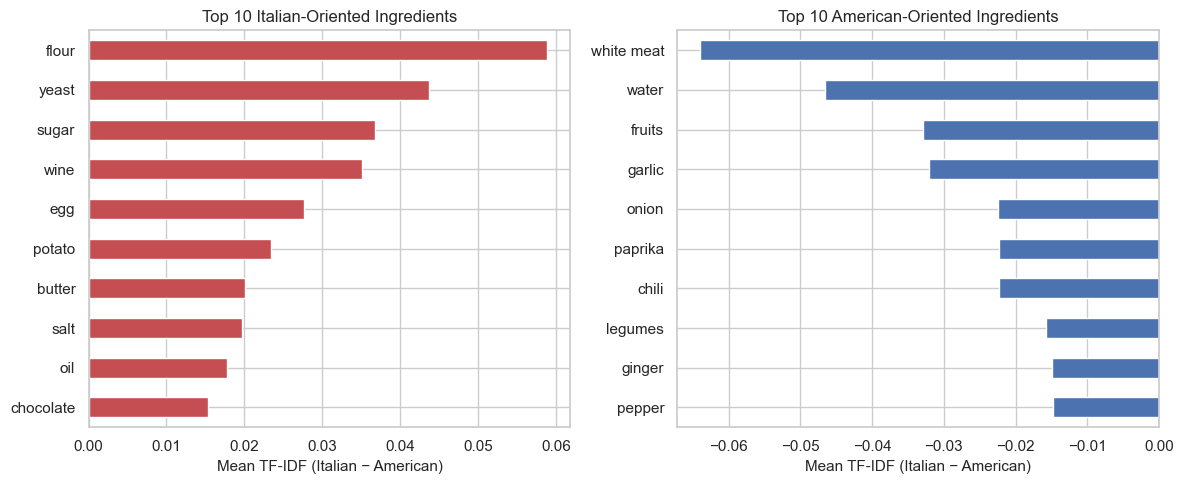

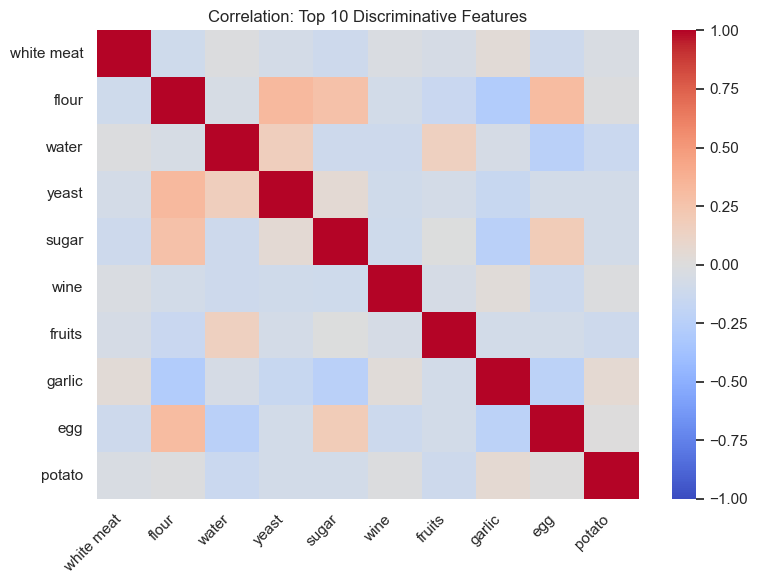

In [4]:
def pretty_name(name):
    return name.replace(".", " ")

fig, ax = plt.subplots(figsize=(6, 4))
balance = y.value_counts().sort_index()
labels = ["American (1)", "Italian (2)"]
sns.barplot(x=labels, y=balance.values, hue=labels, legend=False, ax=ax, palette="muted")
ax.set_title("Class Balance (Training Set)")
ax.set_ylabel("Count")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

mean_american = X[y == 1].mean()
mean_italian = X[y == 2].mean()
diff = mean_italian - mean_american

top_italian = diff.nlargest(10)
top_american = diff.nsmallest(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
top_italian.sort_values().plot.barh(ax=axes[0], color="#c44e52")
axes[0].set_title("Top 10 Italian-Oriented Ingredients")
axes[0].set_xlabel("Mean TF-IDF (Italian − American)")
axes[0].set_yticklabels([pretty_name(i) for i in top_italian.sort_values().index])
top_american.sort_values(ascending=False).plot.barh(ax=axes[1], color="#4c72b0")
axes[1].set_title("Top 10 American-Oriented Ingredients")
axes[1].set_xlabel("Mean TF-IDF (Italian − American)")
axes[1].set_yticklabels([pretty_name(i) for i in top_american.sort_values(ascending=False).index])
plt.tight_layout()
plt.show()

top_features = diff.abs().nlargest(10).index
corr = X[top_features].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=False, cmap="coolwarm", center=0, vmin=-1, vmax=1,
    xticklabels=[pretty_name(f) for f in top_features],
    yticklabels=[pretty_name(f) for f in top_features], ax=ax,
)
ax.set_title("Correlation: Top 10 Discriminative Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 4. Linear Baselines

In [5]:
def cv_mean_accuracy(estimator, X, y, cv, n_jobs=-1):
    return cross_val_score(
        estimator, X, y, cv=cv, scoring="accuracy", n_jobs=n_jobs
    ).mean()


def cv_accuracy(model_family, model_name, estimator, n_jobs=-1):
    scores = cross_validate(
        estimator, X, y, cv=cv, scoring=["accuracy"], n_jobs=n_jobs
    )
    return {
        "Model Family": model_family,
        "Model": model_name,
        "Mean CV Accuracy": scores["test_accuracy"].mean(),
        "Std": scores["test_accuracy"].std(),
    }


def evaluate_model(name, estimator, X, y, cv, n_jobs=-1):
    scores = cross_validate(
        estimator, X, y, cv=cv,
        scoring=["accuracy", "balanced_accuracy"],
        n_jobs=n_jobs,
    )
    return {
        "Model": name,
        "Mean CV Accuracy": scores["test_accuracy"].mean(),
        "Std": scores["test_accuracy"].std(),
        "Mean Balanced Accuracy": scores["test_balanced_accuracy"].mean(),
    }


pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(C=1.0, max_iter=5000, random_state=RANDOM_STATE)),
])
pipe_lsvc = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(C=1.0, max_iter=5000, random_state=RANDOM_STATE)),
])

linear_results = [
    cv_accuracy("Linear", "Logistic Regression", pipe_lr),
    cv_accuracy("Linear", "LinearSVC", pipe_lsvc),
]
linear_results_df = pd.DataFrame(linear_results)
linear_results_df


,Model Family,Model,Mean CV Accuracy,Std
0,Linear,Logistic Regression,0.779375,0.019476
1,Linear,LinearSVC,0.777813,0.020334


## 5. Nonlinear Model Benchmark

In [6]:
pipe_rbf_default = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", probability=True, C=1.0, gamma="scale")),
])

nonlinear_benchmark_results = [
    cv_accuracy("Tree Ensembles", "RandomForest",
        RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
    cv_accuracy("Tree Ensembles", "HistGradientBoosting",
        HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
    cv_accuracy("Tree Ensembles", "ExtraTrees",
        ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
    cv_accuracy("Kernel Methods", "RBF SVM", pipe_rbf_default),
]
nonlinear_benchmark_df = pd.DataFrame(nonlinear_benchmark_results)

family_order = {"Linear": 0, "Tree Ensembles": 1, "Kernel Methods": 2}
model_benchmark_df = pd.concat([linear_results_df, nonlinear_benchmark_df], ignore_index=True)
model_benchmark_df["_order"] = model_benchmark_df["Model Family"].map(family_order)
model_benchmark_df = (
    model_benchmark_df.sort_values(["_order", "Mean CV Accuracy"], ascending=[True, False])
    .drop(columns="_order")
    .reset_index(drop=True)
)
model_benchmark_df


,Model Family,Model,Mean CV Accuracy,Std
0,Linear,Logistic Regression,0.779375,0.019476
1,Linear,LinearSVC,0.777813,0.020334
2,Tree Ensembles,ExtraTrees,0.920937,0.006297
3,Tree Ensembles,RandomForest,0.915000,0.005813
4,Tree Ensembles,HistGradientBoosting,0.904687,0.009270
5,Kernel Methods,RBF SVM,0.883437,0.017247


## 6. Focused Hyperparameter Tuning (Optuna)

### 6.1 ExtraTrees


In [7]:
def objective_extratrees(trial):
    model = ExtraTreesClassifier(
        n_estimators=trial.suggest_int("n_estimators", 300, 1000),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 8),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 15),
        max_depth=trial.suggest_categorical("max_depth", [None, 10, 20, 30]),
        criterion=trial.suggest_categorical("criterion", ["gini", "entropy"]),
        bootstrap=trial.suggest_categorical("bootstrap", [False, True]),
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    return cv_mean_accuracy(model, X, y, cv)


study_et = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name="ExtraTrees",
)
study_et.optimize(objective_extratrees, n_trials=N_TRIALS, show_progress_bar=False)

print(f"ExtraTrees — best CV accuracy: {study_et.best_value:.4f}")
et_best_params_df = pd.DataFrame([study_et.best_params])
et_best_params_df


ExtraTrees — best CV accuracy: 0.9241


,n_estimators,max_features,min_samples_leaf,min_samples_split,max_depth,criterion,bootstrap
0,353,log2,1,5,None,gini,False


### 6.2 RBF SVM


In [8]:
def objective_rbf_svm(trial):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            C=trial.suggest_float("C", 1e-2, 1e3, log=True),
            gamma=trial.suggest_float("gamma", 1e-5, 1.0, log=True),
            class_weight=trial.suggest_categorical("class_weight", [None, "balanced"]),
            shrinking=trial.suggest_categorical("shrinking", [True, False]),
            tol=trial.suggest_float("tol", 1e-5, 1e-2, log=True),
        )),
    ])
    return cross_val_score(
        pipeline, X, y, cv=cv, scoring="accuracy", n_jobs=1
    ).mean()


study_svm = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name="RBF_SVM",
)
study_svm.optimize(objective_rbf_svm, n_trials=N_TRIALS, show_progress_bar=False)

print(f"RBF SVM — best CV accuracy: {study_svm.best_value:.4f}")
svm_best_params_df = pd.DataFrame([study_svm.best_params])
svm_best_params_df


RBF SVM — best CV accuracy: 0.9181


,C,gamma,class_weight,shrinking,tol
0,4.504637,0.056095,None,False,0.000204


### 6.3 Save best parameters


In [9]:
best_params = {
    "ExtraTrees": dict(study_et.best_params),
    "RBF_SVM": {
        "C": study_svm.best_params["C"],
        "gamma": study_svm.best_params["gamma"],
        "class_weight": study_svm.best_params.get("class_weight"),
        "shrinking": study_svm.best_params["shrinking"],
        "tol": study_svm.best_params["tol"],
    },
}

params_out = DATA_DIR / "best_params.json"
with open(params_out, "w") as f:
    json.dump(best_params, f, indent=2)

tuning_summary_df = pd.DataFrame([
    {"Model": "ExtraTrees", "Best CV Accuracy": study_et.best_value},
    {"Model": "RBF SVM", "Best CV Accuracy": study_svm.best_value},
])
print(f"Saved: {params_out}")
tuning_summary_df


def make_extratrees(seed=RANDOM_STATE):
    return ExtraTreesClassifier(
        **best_params["ExtraTrees"], random_state=seed, n_jobs=-1
    )


def make_rbf_svm():
    p = best_params["RBF_SVM"]
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            C=p["C"],
            gamma=p["gamma"],
            class_weight=p.get("class_weight"),
            shrinking=p.get("shrinking", True),
            tol=p.get("tol", 1e-3),
        )),
    ])


Saved: best_params.json


## 7. Tuned Models — Cross-Validation

In [10]:
tuned_results_df = pd.DataFrame([
    evaluate_model("ExtraTrees (tuned)", make_extratrees(), X, y, cv),
    evaluate_model("RBF SVM (tuned)", make_rbf_svm(), X, y, cv, n_jobs=1),
])
tuned_results_df


,Model,Mean CV Accuracy,Std,Mean Balanced Accuracy
0,ExtraTrees (tuned),0.924063,0.005376,0.92359
1,RBF SVM (tuned),0.918125,0.012601,0.91805


## 8. Model Diversity Analysis

Different predictions: 72 / 1734 (4.2%)


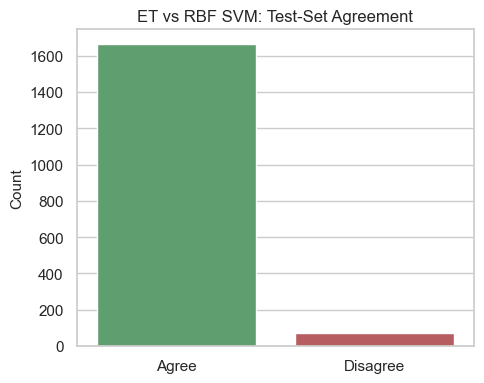

In [11]:
et_model = make_extratrees()
svm_model = make_rbf_svm()
et_model.fit(X, y)
svm_model.fit(X, y)

preds_et = et_model.predict(X_test)
preds_svm = svm_model.predict(X_test)

n_different = int((preds_et != preds_svm).sum())
pct_different = 100 * n_different / len(X_test)

print(f"Different predictions: {n_different} / {len(X_test)} ({pct_different:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
agree = len(X_test) - n_different
sns.barplot(
    x=["Agree", "Disagree"],
    y=[agree, n_different],
    hue=["Agree", "Disagree"],
    legend=False,
    palette=["#55a868", "#c44e52"],
    ax=ax,
)
ax.set_title("ET vs RBF SVM: Test-Set Agreement")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## 9. Final Ensemble

**Final solution:** Soft Voting Ensemble

- **Components:** ExtraTrees (tuned), RBF SVM (tuned)
- **Weights:** [3, 1] on predicted class probabilities
- **Voting:** soft — for class \(k\), \(s_k = \sum_i w_i \, p_i(k)\); predict \(\arg\max_k s_k\)


In [12]:
final_voting = VotingClassifier(
    estimators=[("et", make_extratrees()), ("svm", make_rbf_svm())],
    voting="soft",
    weights=[3, 1],
)

ensemble_row = cv_accuracy("Ensemble", "ET + RBF Voting", final_voting, n_jobs=1)

story_rows = linear_results + [
    {
        "Model Family": "Tree Ensembles",
        "Model": "ExtraTrees (tuned)",
        "Mean CV Accuracy": tuned_results_df.loc[0, "Mean CV Accuracy"],
        "Std": tuned_results_df.loc[0, "Std"],
    },
    {
        "Model Family": "Kernel Methods",
        "Model": "RBF SVM (tuned)",
        "Mean CV Accuracy": tuned_results_df.loc[1, "Mean CV Accuracy"],
        "Std": tuned_results_df.loc[1, "Std"],
    },
    ensemble_row,
]
story_comparison_df = pd.DataFrame(story_rows)[
    ["Model Family", "Model", "Mean CV Accuracy", "Std"]
].sort_values("Mean CV Accuracy", ascending=False).reset_index(drop=True)

story_comparison_df


,Model Family,Model,Mean CV Accuracy,Std
0,Ensemble,ET + RBF Voting,0.927187,0.007881
1,Tree Ensembles,ExtraTrees (tuned),0.924063,0.005376
2,Kernel Methods,RBF SVM (tuned),0.918125,0.012601
3,Linear,Logistic Regression,0.779375,0.019476
4,Linear,LinearSVC,0.777813,0.020334


## 10. Feature Importance & Ingredient Signals

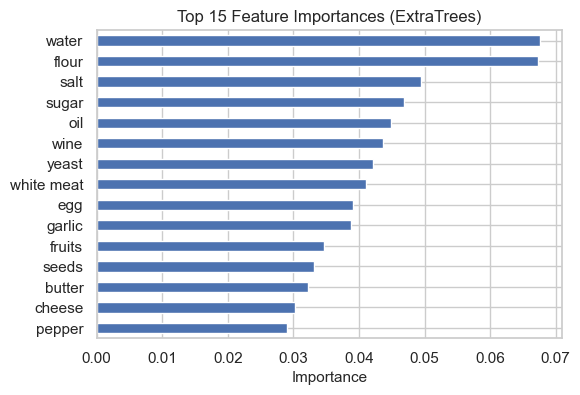

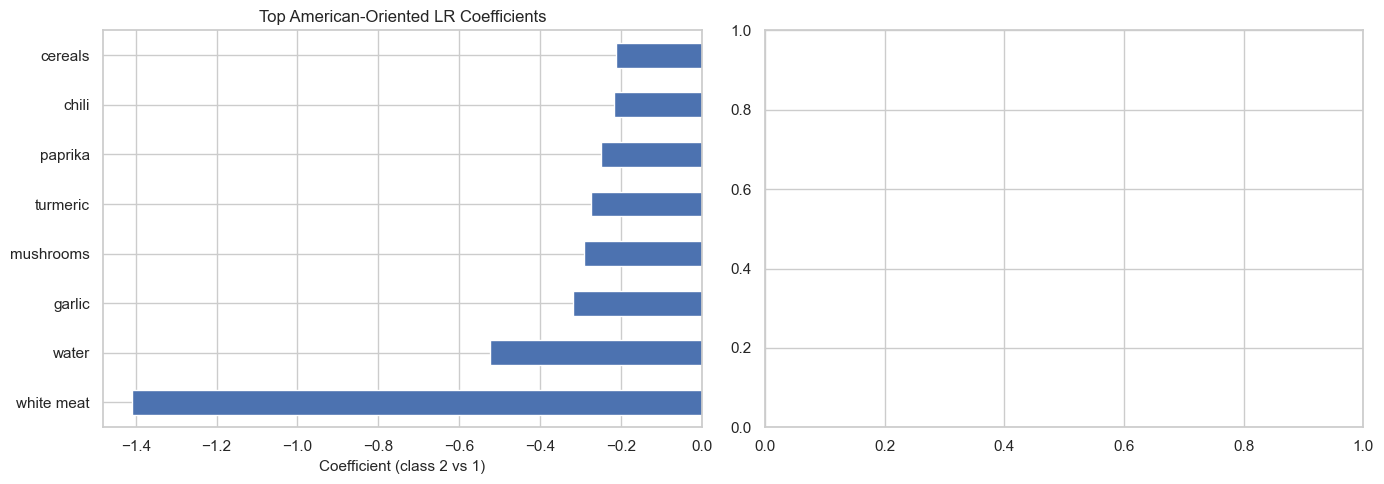

<Figure size 800x400 with 0 Axes>

In [15]:
et_fitted = make_extratrees()
et_fitted.fit(X, y)
importance = (
    pd.Series(et_fitted.feature_importances_, index=feature_cols)
    .nlargest(15)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(6, 4))
importance.plot.barh(ax=ax, color="#4c72b0")
ax.set_title("Top 15 Feature Importances (ExtraTrees)")
ax.set_xlabel("Importance")
ax.set_yticklabels([pretty_name(i) for i in importance.index])
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pipe_lr.fit(X, y)
coefs = pd.Series(pipe_lr.named_steps["clf"].coef_[0], index=feature_cols)

top_neg = coefs.nsmallest(8).sort_values()
top_neg.plot.barh(ax=axes[0], color="#4c72b0")
axes[0].set_title("Top American-Oriented LR Coefficients")
axes[0].set_xlabel("Coefficient (class 2 vs 1)")
axes[0].set_yticklabels([pretty_name(i) for i in top_neg.index])

top_pos = coefs.nlargest(8).sort_values()
top_pos.plot.barh(ax=axes[1], color="#c44e52")
axes[1].set_title("Top Italian-Oriented LR Coefficients")
axes[1].set_xlabel("Coefficient (class 2 vs 1)")
axes[1].set_yticklabels([pretty_name(i) for i in top_pos.index])

plt.tight_layout()
plt.show()




## 11. Final Training & Submission


In [14]:
final_voting.fit(X, y)
final_predictions = final_voting.predict(X_test)

out_path = DATA_DIR / "submission_voting_et_rbf.txt"
pd.Series(final_predictions).to_csv(out_path, index=False, header=False)

assert len(final_predictions) == len(X_test)
assert set(final_predictions).issubset({1, 2})

print(f"Saved: {out_path}")
print(f"Predictions: {len(final_predictions)}")
print("Class distribution:")
print(pd.Series(final_predictions).value_counts().sort_index())


Saved: submission_voting_et_rbf.txt
Predictions: 1734
Class distribution:
1    916
2    818
Name: count, dtype: int64
